# 0.0. Setup

In [1]:
import re
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from numba import njit, prange
from pathlib import Path
from tqdm import tqdm

pd.set_option('display.max_columns', None)

PROJECT_DIR = Path.cwd().parent
OUTPUT_DIR = PROJECT_DIR / 'output'
SIM_DIR = OUTPUT_DIR / 'constrained_simulation'

print(f'Project directory: {PROJECT_DIR}')

Project directory: /workspace/project_paaral


# 1.0. Load data

In [2]:
# Load school information
fpath = str(OUTPUT_DIR / "processed_project_bukas_school_information.parquet")
sch_info = pd.read_parquet(fpath)
print(f"\nSchool info shape: {sch_info.shape}")

# Create slim version with just the columns we need
essential_cols = [
    "school_id",
    "school_name",
    "old_region",
    "division",
    "sector",
    "offers_es",
    "offers_jhs",
    "offers_shs",
]
sch_info_slim = sch_info[essential_cols].copy()
sch_info_slim["school_id"] = sch_info_slim["school_id"].astype(str)

print(f"School info slim shape: {sch_info_slim.shape}")
print(f"\nSample:")
display(sch_info_slim.head())


School info shape: (61442, 20)
School info slim shape: (61442, 8)

Sample:


,school_id,school_name,old_region,division,sector,offers_es,offers_jhs,offers_shs
0,100001,Apaleng-Libtong ES,Region I,Ilocos Norte,Public,True,False,False
1,100002,Bacarra CES,Region I,Ilocos Norte,Public,True,False,False
2,100003,Buyon ES,Region I,Ilocos Norte,Public,True,False,False
3,100004,Ganagan Elementary School,Region I,Ilocos Norte,Public,True,False,False
4,100005,Macupit ES,Region I,Ilocos Norte,Public,True,False,False


In [122]:
# Observed student flow for ALL schools
student_flow = pd.read_parquet(OUTPUT_DIR / 'grade_7_student_flow_table_sy2324.parquet')
print(f"Shape of student flow dataframe: {student_flow.shape}")
print(f"Count of unique origin schools offering Grade 6: {student_flow['school_id_origin'].nunique()}")

Shape of student flow dataframe: (288328, 4)
Count of unique origin schools offering Grade 6: 47179


In [5]:
# Display first rows of student flow
display(student_flow.head())

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary
0,100000,300378,8.0,NaN
1,100000,300388,25.0,NaN
2,100000,305334,1.0,NaN
3,100000,500057,2.0,NaN
4,100001,300002,6.0,NaN


In [126]:
# ESC slots
esc_slots = pd.read_parquet(OUTPUT_DIR / 'processed_esc_slots.parquet')
print(f"Shape of PEAC ESC slots dataset: {esc_slots.shape}")
print(f"SY 23-24 total slots: {esc_slots['slots_billed'].sum():,.0f}")
# display(esc_slots.head(1))

Shape of PEAC ESC slots dataset: (4638, 7)
SY 23-24 total slots: 226,483


In [6]:
# Predicted flow from NBR
cbp = pd.read_parquet(OUTPUT_DIR / 'full_candidate_beneficiary_pool_without_probdist_0209_clusteredSE.parquet')
cbp['origin_school_id'] = cbp['origin_school_id'].astype(str)
cbp['destination_school_id'] = cbp['destination_school_id'].astype(str)

# Vectorized: create composite keys and check membership
existing_keys = set(
    student_flow['school_id_origin'] + '_' + student_flow['school_id_destination']
)
cbp_keys = cbp['origin_school_id'] + '_' + cbp['destination_school_id']
cbp['is_hypothetical'] = ~cbp_keys.isin(existing_keys)

print(cbp.shape)

(325395, 69)


In [ ]:
cbp_mm = 

## 1.1. Checks

In [7]:
display(student_flow.head(2))

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary
0,100000,300378,8.0,NaN
1,100000,300388,25.0,NaN


In [113]:
student_flow.loc[:,"count_non_beneficiary":].sum()


count_non_beneficiary    1579844.0
count_esc_beneficiary     209072.0
dtype: float64

In [8]:
esc_slots[esc_slots['slots_unutilized'] < 0].head(2)

,school_id,esc_school_id,school_name,slots_total,slots_billed,slots_unutilized,has_deped_school_id
24,406758,1402657,"LA SALLE - GREEN HILLS, INC.",50,86,-36,True
29,406482,1404384,"METRO MANILA COLLEGE, INC.",50,70,-20,True


In [9]:
display(cbp.head(2))
display(cbp['is_hypothetical'].value_counts())

,origin_school_id,destination_school_id,origin_sector,origin_region,destination_sector,tuition_fees_k,destination_tuition_fees,distance_meters,distance_km,net_cost,net_cost_k,esc_rating,log_distance,log_tuition,log_net_cost_k,destination_jhs_enrollment,esc_amount,esc_amount_k,candidate_pool,log_origin_lgu_income,log_destination_lgu_income,scaled_origin_income,scaled_dest_income,destination_region,net_cost_baseline_0_subsidy,mu_baseline_0_subsidy,net_cost_current_subsidy,mu_current_subsidy,net_cost_minus_1k_net_cost,mu_minus_1k_net_cost,net_cost_minus_2k_net_cost,mu_minus_2k_net_cost,net_cost_minus_3k_net_cost,mu_minus_3k_net_cost,net_cost_minus_4k_net_cost,mu_minus_4k_net_cost,net_cost_minus_5k_net_cost,mu_minus_5k_net_cost,net_cost_minus_6k_net_cost,mu_minus_6k_net_cost,net_cost_minus_7k_net_cost,mu_minus_7k_net_cost,net_cost_minus_8k_net_cost,mu_minus_8k_net_cost,net_cost_minus_9k_net_cost,mu_minus_9k_net_cost,net_cost_minus_10k_net_cost,mu_minus_10k_net_cost,net_cost_minus_11k_net_cost,mu_minus_11k_net_cost,net_cost_minus_12k_net_cost,mu_minus_12k_net_cost,net_cost_minus_13k_net_cost,mu_minus_13k_net_cost,net_cost_minus_14k_net_cost,mu_minus_14k_net_cost,net_cost_minus_15k_net_cost,mu_minus_15k_net_cost,net_cost_minus_16k_net_cost,mu_minus_16k_net_cost,net_cost_minus_17k_net_cost,mu_minus_17k_net_cost,net_cost_minus_18k_net_cost,mu_minus_18k_net_cost,net_cost_minus_19k_net_cost,mu_minus_19k_net_cost,net_cost_minus_20k_net_cost,mu_minus_20k_net_cost,is_hypothetical
0,104408,401116,Public,Region III (Central Luzon),Private,18.525,18525.0,215159.4,215.1594,9525.0,9.525,0.0,5.376016,2.971696,2.353753,949.0,9000.0,9.0,71.0,17.718374,18.339095,-1.530478,-1.239907,Region III (Central Luzon),18.525,0.529876,9.525,0.563787,8.525,0.569466,7.525,0.575842,6.525,0.583100,5.525,0.591506,4.525,0.601467,3.525,0.613644,2.525,0.629223,1.525,0.650654,0.525,0.684438,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,False
1,104412,401116,Public,Region III (Central Luzon),Private,18.525,18525.0,216821.4,216.8214,9525.0,9.525,0.0,5.383675,2.971696,2.353753,949.0,9000.0,9.0,83.0,17.718374,18.339095,-1.530478,-1.239907,Region III (Central Luzon),18.525,0.528050,9.525,0.561843,8.525,0.567502,7.525,0.573856,6.525,0.581089,5.525,0.589467,4.525,0.599394,3.525,0.611529,2.525,0.627054,1.525,0.648411,0.525,0.682078,0.0,0.711593,0.0,0.711593,0.0,0.711593,0.0,0.711593,0.0,0.711593,0.0,0.711593,0.0,0.711593,0.0,0.711593,0.0,0.711593,0.0,0.711593,0.0,0.711593,False


is_hypothetical
True     234972
False     90423
Name: count, dtype: int64

In [10]:
# Aggregate observed flows by destination schools
flow_dest = student_flow.groupby(['school_id_destination'], as_index=False).agg(
    {'count_non_beneficiary':'sum', 'count_esc_beneficiary':'sum'}
)
flow_dest['school_id_destination'] = flow_dest['school_id_destination'].astype(str)

# Filter observed flows data to only 
# system_ids = cbp['origin_school_id'].values.tolist() + cbp['destination_school_id'].values.tolist()
mask = (
    (flow_dest['school_id_destination'].isin(cbp['origin_school_id'].values))
    | (flow_dest['school_id_destination'].isin(cbp['destination_school_id'].values))
)
flow_dest = flow_dest[mask].copy()
print(flow_dest.shape)
display(flow_dest.head(3))

# Filter slots data to only include schools in system
mask = (
    (esc_slots['school_id'].isin(cbp['origin_school_id'].values))
    | (esc_slots['school_id'].isin(cbp['destination_school_id'].values))
)
system_slots = esc_slots.loc[mask].copy().drop(
    columns=[
        'esc_school_id',
        'school_name',
        'has_deped_school_id',  # all have deped school ids, so drop
    ]
)
system_slots['school_id'] = system_slots['school_id'].astype(str)

# We have duplicating schools IDs, so we combine their slots information
# NOTE: personally, this is an issue
system_slots = system_slots.groupby(['school_id'], as_index=False).agg(
    {
        'slots_total':'sum',
        'slots_billed':'sum',
        'slots_unutilized':'sum',
    }
)
print(system_slots.shape)
display(system_slots.head(3))

# Aggregate predicted flows by destination
id_cols = ['destination_school_id']
cbp_dest = cbp.groupby(id_cols, as_index=False)['mu_current_subsidy'].sum()
cbp_dest['mu_current_subsidy'] = np.floor(cbp_dest['mu_current_subsidy'])
cbp_dest['destination_school_id'] = cbp_dest['destination_school_id'].astype(str)

print(cbp_dest.shape)
display(cbp_dest.head(2))

(2194, 3)


,school_id_destination,count_non_beneficiary,count_esc_beneficiary
8440,400395,18.0,0.0
8518,400593,8.0,24.0
8519,400596,26.0,0.0


(1410, 4)


,school_id,slots_total,slots_billed,slots_unutilized
0,400593,24,32,-8
1,400603,162,183,-21
2,400610,226,218,8


(1373, 2)


,destination_school_id,mu_current_subsidy
0,400593,25.0
1,400603,98.0


In [11]:
# Merge slots and observed flows
mrg1 = system_slots.merge(
    flow_dest,
    left_on='school_id',
    right_on='school_id_destination',
    how='left'
)
ess_cols = [
    'school_id',
    'slots_total','slots_billed','count_esc_beneficiary'
]
mrg1 = mrg1[ess_cols].rename(
    columns={
        'count_esc_beneficiary':'esc_beneficiary_observed'
    }
)
# if observed beneficiary is 0, replace with slots_billed
def use_slots_billed(row):
    billed = row['slots_billed']
    observed = row['esc_beneficiary_observed']
    if observed == 0:
        return billed
    else:
        return observed

mrg1['esc_beneficiary_processed'] = mrg1.apply(
    lambda row: use_slots_billed(row),
    axis=1
)
print(mrg1.shape)

# Merge
mrg2 = mrg1.merge(
    cbp_dest,
    left_on='school_id',
    right_on='destination_school_id',
    how='left'
).drop(columns=['destination_school_id'])
print(mrg2.shape)

(1410, 5)
(1410, 6)


# 2.0. Analysis

## 2.1. EDA

In [12]:
display(mrg2.head(2))

,school_id,slots_total,slots_billed,esc_beneficiary_observed,esc_beneficiary_processed,mu_current_subsidy
0,400593,24,32,24.0,24.0,25.0
1,400603,162,183,158.0,158.0,98.0


In [13]:
# Plot slots_total & slots_billed to check for outliers
mask = mrg2['mu_current_subsidy'].isna()
df_an = mrg2.loc[~mask].copy()

# Label schools with surplus, deficit, balanced
def categorize_slot_utilization(row):
    total = row['slots_total']
    billed = row['slots_billed']

    if total == billed:
        return 'balanced'
    elif total > billed:
        return 'surplus'
    elif total < billed:
        return 'deficit'
    
df_an['slots_category'] = df_an.apply(lambda row: categorize_slot_utilization(row), axis=1)

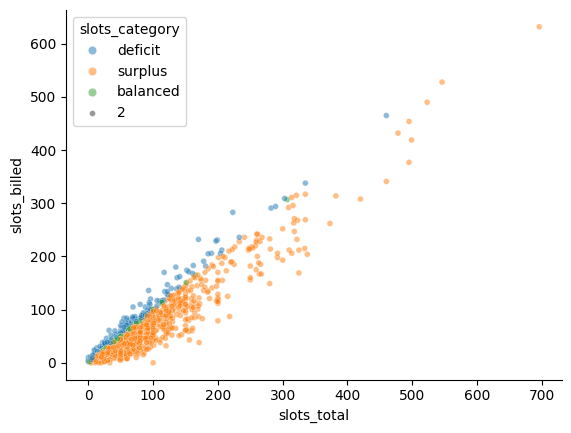

In [14]:
# I found no insight in doing this (so far)
fig, ax = plt.subplots()
ax.spines[['top','right']].set_visible(False)

sns.scatterplot(
    data=df_an,
    x='slots_total',
    y='slots_billed',
    hue='slots_category',
    size=2,
    alpha=.5,
    ax=ax,
)

plt.show()
plt.close()

In [15]:
cbp.head(1)

,origin_school_id,destination_school_id,origin_sector,origin_region,destination_sector,tuition_fees_k,destination_tuition_fees,distance_meters,distance_km,net_cost,net_cost_k,esc_rating,log_distance,log_tuition,log_net_cost_k,destination_jhs_enrollment,esc_amount,esc_amount_k,candidate_pool,log_origin_lgu_income,log_destination_lgu_income,scaled_origin_income,scaled_dest_income,destination_region,net_cost_baseline_0_subsidy,mu_baseline_0_subsidy,net_cost_current_subsidy,mu_current_subsidy,net_cost_minus_1k_net_cost,mu_minus_1k_net_cost,net_cost_minus_2k_net_cost,mu_minus_2k_net_cost,net_cost_minus_3k_net_cost,mu_minus_3k_net_cost,net_cost_minus_4k_net_cost,mu_minus_4k_net_cost,net_cost_minus_5k_net_cost,mu_minus_5k_net_cost,net_cost_minus_6k_net_cost,mu_minus_6k_net_cost,net_cost_minus_7k_net_cost,mu_minus_7k_net_cost,net_cost_minus_8k_net_cost,mu_minus_8k_net_cost,net_cost_minus_9k_net_cost,mu_minus_9k_net_cost,net_cost_minus_10k_net_cost,mu_minus_10k_net_cost,net_cost_minus_11k_net_cost,mu_minus_11k_net_cost,net_cost_minus_12k_net_cost,mu_minus_12k_net_cost,net_cost_minus_13k_net_cost,mu_minus_13k_net_cost,net_cost_minus_14k_net_cost,mu_minus_14k_net_cost,net_cost_minus_15k_net_cost,mu_minus_15k_net_cost,net_cost_minus_16k_net_cost,mu_minus_16k_net_cost,net_cost_minus_17k_net_cost,mu_minus_17k_net_cost,net_cost_minus_18k_net_cost,mu_minus_18k_net_cost,net_cost_minus_19k_net_cost,mu_minus_19k_net_cost,net_cost_minus_20k_net_cost,mu_minus_20k_net_cost,is_hypothetical
0,104408,401116,Public,Region III (Central Luzon),Private,18.525,18525.0,215159.4,215.1594,9525.0,9.525,0.0,5.376016,2.971696,2.353753,949.0,9000.0,9.0,71.0,17.718374,18.339095,-1.530478,-1.239907,Region III (Central Luzon),18.525,0.529876,9.525,0.563787,8.525,0.569466,7.525,0.575842,6.525,0.5831,5.525,0.591506,4.525,0.601467,3.525,0.613644,2.525,0.629223,1.525,0.650654,0.525,0.684438,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,0.0,0.714055,False


In [16]:
df_an.head(1)

,school_id,slots_total,slots_billed,esc_beneficiary_observed,esc_beneficiary_processed,mu_current_subsidy,slots_category
0,400593,24,32,24.0,24.0,25.0,deficit


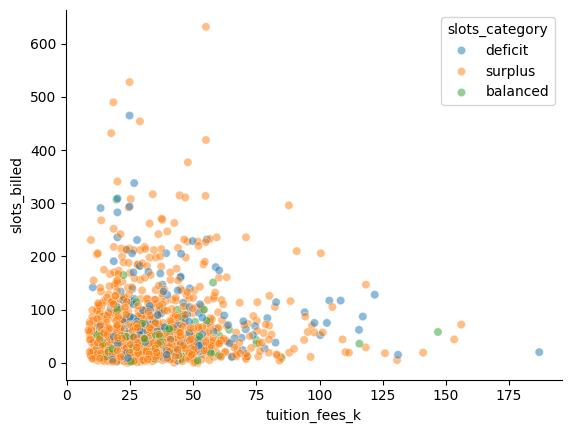

In [17]:
# Let's check relationshop of tuition
dest_tuition = (
    cbp
    .groupby(['destination_school_id'], as_index=False)['tuition_fees_k'].mean()
    .rename(columns={'destination_school_id':'school_id'})
)

mrg2_php = df_an.merge(
    dest_tuition,
    on='school_id',
    how='left'
)
# print(mrg2_php.shape)

mask = mrg2_php['tuition_fees_k'] > 0
mrg2_php = mrg2_php.loc[mask]


fig, ax = plt.subplots()
ax.spines[['top','right']].set_visible(False)

sns.scatterplot(
    data=mrg2_php,
    x='tuition_fees_k',
    y='slots_billed',
    hue='slots_category',
    # size='slots_billed',
    alpha=.5,
    ax=ax,
)

plt.show()
plt.close()

In [18]:
mrg2_php.isna().sum()

school_id                    0
slots_total                  0
slots_billed                 0
esc_beneficiary_observed     3
esc_beneficiary_processed    3
mu_current_subsidy           0
slots_category               0
tuition_fees_k               0
dtype: int64

## 2.2. Validation

In [19]:
# # Filter out NaNs in predicted mu
# mask = mrg2['mu_current_subsidy'].isna()
# df_an = mrg2.loc[~mask].copy()

slots_total = df_an['slots_total'].sum()
slots_billed = df_an['slots_billed'].sum()
slot_ulit = (slots_billed / slots_total) * 100
# print(df_an.shape)
print(f"Total pre-filled system slots: {slots_total:,.0f}")
print(f"Total billed system slots: {slots_billed:,.0f}")
print(f"System slot utilization: {slot_ulit:,.2f}%")

df_an['abs_diff_billed_mu'] = df_an['mu_current_subsidy'] - df_an['slots_billed']
mean_abs_diff = df_an['abs_diff_billed_mu'].mean()
std_abs_diff = df_an['abs_diff_billed_mu'].std()
print(f"Mean of the absolute difference between predicted mu & slots billed is: {mean_abs_diff:,.0f} students")
print(f"Std of the absolute difference between predicted mu & slots billed is: {std_abs_diff:,.0f} students")

Total pre-filled system slots: 106,654
Total billed system slots: 82,071
System slot utilization: 76.95%
Mean of the absolute difference between predicted mu & slots billed is: 550 students
Std of the absolute difference between predicted mu & slots billed is: 721 students


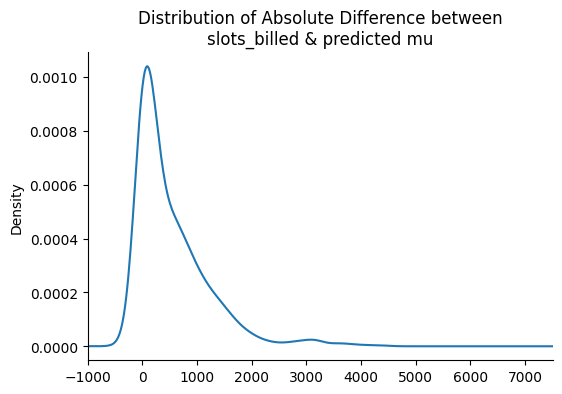

In [20]:
fig, ax = plt.subplots(figsize=(6,4))

# sns.boxplot(
#     data=df_an,
#     y='abs_diff_billed_mu',
# )
df_an['abs_diff_billed_mu'].plot(
    ax=ax,
    kind='kde'
)
ax.set_title('Distribution of Absolute Difference between\nslots_billed & predicted mu')
ax.set_xlim(-1_000, 7_500)
ax.spines[['top','right']].set_visible(False)

plt.show()
plt.close()

# 3.0. Policy Simulation
- We will do simulations guided by our main goal of decongestion

In [21]:
display(df_an.head(1))

,school_id,slots_total,slots_billed,esc_beneficiary_observed,esc_beneficiary_processed,mu_current_subsidy,slots_category,abs_diff_billed_mu
0,400593,24,32,24.0,24.0,25.0,deficit,-7.0


In [22]:
display(student_flow.head(1))

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary
0,100000,300378,8.0,NaN


In [23]:
# Recreate the origin student pool that walked paths within the system (BoSY)
# G6 enrollment is not appropriate becase of the possibility than some
# may have studied outside Mega Manila and, therefore, outside the scope of this study
# Aggregate observed flows by destination schools
flow_og = student_flow.groupby(['school_id_origin'], as_index=False).agg(
    {'count_non_beneficiary':'sum', 'count_esc_beneficiary':'sum'}
)
flow_og['school_id_origin'] = flow_og['school_id_origin'].astype(str)

# Filter observed flows data to only 
mask = (
    (flow_og['school_id_origin'].isin(cbp['origin_school_id'].values))
    | (flow_og['school_id_origin'].isin(cbp['destination_school_id'].values))
)
flow_og = flow_og[mask].copy()
print(flow_og.shape)
# display(flow_og.head(3))


df_cand_pool = flow_og.groupby(['school_id_origin'], as_index=False).agg(
    {'count_non_beneficiary':'sum', 'count_esc_beneficiary':'sum'}
)
df_cand_pool['candidate_pool'] = df_cand_pool.loc[:,"count_non_beneficiary":].sum(axis=1)
ess_cols = ['school_id_origin', 'candidate_pool']
# display(df_cand_pool.head(2))
print(f"Candidate pool is: {df_cand_pool['candidate_pool'].sum():,.0f}")
print(f"Count of learners that became ESC beneficiaries: {df_cand_pool['count_esc_beneficiary'].sum():,.0f}")
print(f"Count of BoSY system slots: {system_slots['slots_total'].sum():,.0f}")
print(f"Count of billed system slots: {system_slots['slots_billed'].sum():,.0f}")

mask = system_slots['slots_unutilized'] > 0
slots_unutilized = system_slots.loc[mask, 'slots_total'] - system_slots.loc[mask, 'slots_billed']
print(f"Count of unutilized slots in system: {slots_unutilized.sum():,.0f}")

mask = system_slots['slots_unutilized'] < 0
deficit_slots = system_slots.loc[mask,'slots_unutilized'].sum()
print(f"Count of BoSY slots > prefilled slots: {deficit_slots.sum():,.0f}")

(7662, 3)
Candidate pool is: 563,239
Count of learners that became ESC beneficiaries: 73,794
Count of BoSY system slots: 106,770
Count of billed system slots: 82,168
Count of unutilized slots in system: 26,352
Count of BoSY slots > prefilled slots: -1,750


In [24]:
26352 + 82168 - 1750

106770

In [25]:
flow_og.head(2)

,school_id_origin,count_non_beneficiary,count_esc_beneficiary
1607,101701,41.0,0.0
2075,102178,45.0,0.0


In [115]:
# ACTUAL: Mega Manila ESC Bene flows
flow_og['count_esc_beneficiary'].sum() --> 73_794

# PREDICTED using NBR:
# Total predicted flow:
99_884

np.float64(73794.0)

In [26]:
df_cand_pool.head(2)

,school_id_origin,count_non_beneficiary,count_esc_beneficiary,candidate_pool
0,101701,41.0,0.0,41.0
1,102178,45.0,0.0,45.0


In [27]:
display(df_an.head(1))

,school_id,slots_total,slots_billed,esc_beneficiary_observed,esc_beneficiary_processed,mu_current_subsidy,slots_category,abs_diff_billed_mu
0,400593,24,32,24.0,24.0,25.0,deficit,-7.0


## 3.1. Function

In [28]:
# Create tracker: pool of students to be simulated
CAND_POOL = df_cand_pool[ess_cols].set_index('school_id_origin').to_dict()['candidate_pool']

# Create tracker: 
SLOT_POOL = df_an[
    ['school_id','slots_total']
].set_index('school_id').to_dict()['slots_total']

In [29]:
# Pre-extract static arrays (reused across all scenarios and iterations)
ARR_ORIGIN = cbp['origin_school_id'].values
ARR_DEST = cbp['destination_school_id'].values
ARR_HYPO = cbp['is_hypothetical'].values
ARR_MU = cbp['mu_current_subsidy'].values
N_PATHS = len(cbp)

In [30]:
def run_simulation(mu_values, cand_pool_init, slot_pool_init, seed):
    """
    Run one iteration of the constrained path simulation.
    
    Args:
        mu_values: numpy array of mu values for the chosen scenario
        cand_pool_init: Dict of origin_school_id -> candidate count (initial state)
        slot_pool_init: Dict of destination_school_id -> available slots (initial state)
        seed: Random seed for shuffling
    
    Returns:
        Dict with total_existing, total_hypothetical, total_both
    """
    # Copy trackers (fresh for each iteration)
    tracker_cand = dict(cand_pool_init)
    tracker_slots = dict(slot_pool_init)
    
    # Running totals for early termination
    remaining_cand = sum(cand_pool_init.values())
    remaining_slots = sum(slot_pool_init.values())
    
    # Shuffle indices (avoids DataFrame.sample overhead)
    rng = np.random.default_rng(seed)
    indices = np.arange(N_PATHS)
    rng.shuffle(indices)
    
    total_existing = 0.0
    total_hypothetical = 0.0
    
    for idx in indices:
        # Early termination if either resource is fully depleted
        if remaining_cand <= 0 or remaining_slots <= 0:
            break
        
        mu_val = mu_values[idx]
        if mu_val <= 0 or np.isnan(mu_val):
            continue
        
        og_id = ARR_ORIGIN[idx]
        dest_id = ARR_DEST[idx]
        
        current_pool = tracker_cand.get(og_id, 0)
        current_slots = tracker_slots.get(dest_id, 0)
        
        # Coupled depletion: both must have capacity
        if current_pool > 0 and current_slots > 0:
            accepted = min(current_pool, current_slots, mu_val)
            tracker_cand[og_id] -= accepted
            tracker_slots[dest_id] -= accepted
            remaining_cand -= accepted
            remaining_slots -= accepted
            
            if ARR_HYPO[idx]:
                total_hypothetical += accepted
            else:
                total_existing += accepted
    
    return {
        'total_existing': total_existing,
        'total_hypothetical': total_hypothetical,
        'total_both': total_existing + total_hypothetical,
        'remaining_candidates': remaining_cand,
        'remaining_slots': remaining_slots,
    }

print(f"Simulation function defined. Pre-extracted {N_PATHS:,} paths.")

Simulation function defined. Pre-extracted 325,395 paths.


In [31]:
def run_simulation_detailed(mu_values, cand_pool_init, slot_pool_init, seed):
    """
    Variant of run_simulation that additionally tracks school-level accepted amounts.
    
    Returns:
        Dict with system-level totals PLUS:
        - per_dest: {dest_id: [existing, hypothetical]} accepted per ESC school
        - per_origin: {origin_id: [existing, hypothetical]} accepted per origin
    """
    tracker_cand = dict(cand_pool_init)
    tracker_slots = dict(slot_pool_init)
    remaining_cand = sum(cand_pool_init.values())
    remaining_slots = sum(slot_pool_init.values())
    
    rng = np.random.default_rng(seed)
    indices = np.arange(N_PATHS)
    rng.shuffle(indices)
    
    total_existing = 0.0
    total_hypothetical = 0.0
    
    per_dest = {}    # {dest_id: [existing, hypothetical]}
    per_origin = {}  # {origin_id: [existing, hypothetical]}
    
    for idx in indices:
        if remaining_cand <= 0 or remaining_slots <= 0:
            break
        
        mu_val = mu_values[idx]
        if mu_val <= 0 or np.isnan(mu_val):
            continue
        
        og_id = ARR_ORIGIN[idx]
        dest_id = ARR_DEST[idx]
        
        current_pool = tracker_cand.get(og_id, 0)
        current_slots = tracker_slots.get(dest_id, 0)
        
        if current_pool > 0 and current_slots > 0:
            accepted = min(current_pool, current_slots, mu_val)
            tracker_cand[og_id] -= accepted
            tracker_slots[dest_id] -= accepted
            remaining_cand -= accepted
            remaining_slots -= accepted
            
            is_hypo = ARR_HYPO[idx]
            slot = 1 if is_hypo else 0  # index: 0=existing, 1=hypothetical
            
            if is_hypo:
                total_hypothetical += accepted
            else:
                total_existing += accepted
            
            # Track per destination ESC school
            if dest_id not in per_dest:
                per_dest[dest_id] = [0.0, 0.0]
            per_dest[dest_id][slot] += accepted
            
            # Track per origin
            if og_id not in per_origin:
                per_origin[og_id] = [0.0, 0.0]
            per_origin[og_id][slot] += accepted
    
    return {
        'total_existing': total_existing,
        'total_hypothetical': total_hypothetical,
        'total_both': total_existing + total_hypothetical,
        'remaining_candidates': remaining_cand,
        'remaining_slots': remaining_slots,
        'per_dest': per_dest,
        'per_origin': per_origin,
    }

print("Detailed simulation function defined.")

Detailed simulation function defined.


## 3.2. Current Subsidy

### 3.2.1. Aggregate

In [28]:
# Test with a single iteration first
test_mu = cbp['mu_current_subsidy'].values

test_result = run_simulation(
    mu_values=test_mu,
    cand_pool_init=CAND_POOL,
    slot_pool_init=SLOT_POOL,
    seed=42
)

print("=== Single Iteration Test (current_subsidy) ===")
for k, v in test_result.items():
    print(f"  {k}: {v:,.1f}")

=== Single Iteration Test (current_subsidy) ===
  total_existing: 58,030.6
  total_hypothetical: 41,882.7
  total_both: 99,913.2
  remaining_candidates: 463,325.8
  remaining_slots: 6,740.8


In [95]:
# N_ITERATIONS = 50
# SCENARIO_TO_RUN = 'mu_current_subsidy'  # Adjust as needed

# # Extract mu array once for this scenario
# mu_arr = cbp[SCENARIO_TO_RUN].values

# results = []
# for i in tqdm(range(N_ITERATIONS)):
#     result = run_simulation(
#         mu_values=mu_arr,
#         cand_pool_init=CAND_POOL,
#         slot_pool_init=SLOT_POOL,
#         seed=i
#     )
#     result['seed'] = i
#     results.append(result)

# mc_results = pd.DataFrame(results)
# print(f"\nCompleted {N_ITERATIONS} iterations.")

In [48]:
# display(
#     mc_results
#     .style.format(
#         {
#             'total_existing':'{:,.0f}',
#             'total_hypothetical':'{:,.0f}',
#             'total_both':'{:,.0f}',
#             'remaining_candidates':'{:,.0f}',
#             'remaining_slots':'{:,.0f}',
#         }
#     )
# )

### 3.2.2. School-level

In [74]:
# Run Monte Carlo with detailed school-level tracking
N_ITER_DETAILED = 200
DETAILED_SCENARIO = 'mu_current_subsidy'
mu_detailed = cbp[DETAILED_SCENARIO].values

detailed_results = []
for i in tqdm(range(N_ITER_DETAILED), desc="Detailed MC"):
    result = run_simulation_detailed(
        mu_values=mu_detailed,
        cand_pool_init=CAND_POOL,
        slot_pool_init=SLOT_POOL,
        seed=i
    )
    detailed_results.append(result)

print(f"Completed {N_ITER_DETAILED} detailed iterations.")

# Sanity check: system-level totals should match Section 7
mean_both = np.mean([r['total_both'] for r in detailed_results])
print(f"System-level mean_both: {mean_both:,.1f} (should match Section 7)")

Detailed MC: 100%|██████████| 200/200 [01:10<00:00,  2.83it/s]

Completed 200 detailed iterations.
System-level mean_both: 99,883.5 (should match Section 7)


In [75]:
# Display keys of resulting detailed results
display(detailed_results[0].keys())

dict_keys(['total_existing', 'total_hypothetical', 'total_both', 'remaining_candidates', 'remaining_slots', 'per_dest', 'per_origin'])

In [76]:
# Table 1: Per ESC school — mean and 95% CI of accepted student flow
# Collect all destination school IDs that appeared across any iteration
all_dest_ids = set()
for r in detailed_results:
    all_dest_ids.update(r['per_dest'].keys())

# Build arrays per school: [n_iterations] for existing, hypothetical
esc_school_stats = []
for dest_id in all_dest_ids:
    existing_vals = []
    hypothetical_vals = []
    for r in detailed_results:
        vals = r['per_dest'].get(dest_id, [0.0, 0.0])
        existing_vals.append(vals[0])
        hypothetical_vals.append(vals[1])
    
    existing_arr = np.array(existing_vals)
    hypothetical_arr = np.array(hypothetical_vals)
    both_arr = existing_arr + hypothetical_arr
    
    esc_school_stats.append({
        'destination_school_id': dest_id,
        'mean_existing': existing_arr.mean(),
        'ci_lo_existing': np.percentile(existing_arr, 2.5),
        'ci_hi_existing': np.percentile(existing_arr, 97.5),
        'mean_hypothetical': hypothetical_arr.mean(),
        'ci_lo_hypothetical': np.percentile(hypothetical_arr, 2.5),
        'ci_hi_hypothetical': np.percentile(hypothetical_arr, 97.5),
        'mean_both': both_arr.mean(),
        'ci_lo_both': np.percentile(both_arr, 2.5),
        'ci_hi_both': np.percentile(both_arr, 97.5),
        'std_both': both_arr.std(),
        'std_existing': existing_arr.std(),                                                                                                                                                
        'std_hypothetical': hypothetical_arr.std(),
    })

esc_ci = pd.DataFrame(esc_school_stats).sort_values(
    by=['ci_lo_existing','std_hypothetical'],
    ascending=[False, True]
).reset_index(drop=True)

# Sanity check
print(f"ESC schools with accepted flow: {len(esc_ci):,}")
print(f"Sum of mean_both across all schools: {esc_ci['mean_both'].sum():,.1f}")
print(f"\n=== Top 5 ESC Schools by Mean Accepted Flow ===\n")
display(
    esc_ci[
        [
            'destination_school_id',
            'mean_existing', 'ci_lo_existing', 'ci_hi_existing',
            'mean_hypothetical', 'ci_lo_hypothetical', 'ci_hi_hypothetical',
            # 'mean_both', 'ci_lo_both', 'ci_hi_both',
            'std_existing','std_hypothetical'
        ]
    ]
    .head(5)
    .style.format({
        'mean_existing': '{:,.0f}',
        'ci_lo_existing': '{:,.0f}',
        'ci_hi_existing': '{:,.0f}',
        'mean_hypothetical': '{:,.0f}',
        'ci_lo_hypothetical': '{:,.0f}',
        'ci_hi_hypothetical': '{:,.0f}',
        # 'mean_both': '{:,.1f}',
        # 'ci_lo_both': '{:,.1f}',
        # 'ci_hi_both': '{:,.1f}',
        'std_existing': '{:,.1f}',
        'std_hypothetical': '{:,.1f}',
    })
)

ESC schools with accepted flow: 1,370
Sum of mean_both across all schools: 99,883.5

=== Top 5 ESC Schools by Mean Accepted Flow ===



,destination_school_id,mean_existing,ci_lo_existing,ci_hi_existing,mean_hypothetical,ci_lo_hypothetical,ci_hi_hypothetical,std_existing,std_hypothetical
0,403235,473,466,479,22,16,29,3.4,3.4
1,401404,463,442,480,60,43,81,9.7,9.7
2,403126,455,434,476,91,70,112,10.7,10.7
3,402732,441,429,450,4,4,4,5.6,0.0
4,401317,434,419,453,61,42,76,9.0,9.0


### 3.2.3. Contribution to Decongestion
The earlier sections (3.2.1 and 3.2.2) answer: "How many students does the ESC system absorb in total, and
per school?" — using Monte Carlo simulation with coupled depletion (both the origin's candidate pool and
the ESC school's slots must have capacity).

Section 3.2.3 goes one step further and asks: "Of those absorbed students, how many contribute to
decongesting overcrowded public schools?"

---
The key ingredient: congested_frac

Not every student who goes to an ESC school would have otherwise gone to a congested public JHS. Some
would have gone to uncongested ones.

So for each ESC school, we compute a congested-feeding fraction: what share of its predicted demand comes
from elementary school origins that also feed congested public JHS?

Example: ESC School X draws students from 10 elementary schools. 8 of those origins also send students to
overcrowded public JHS. If those 8 origins account for 90% of ESC School X's predicted demand, then
congested_frac = 0.90.

System-wide, this fraction averages 94.4% — most ESC demand comes from origins that also feed congested
schools.

In [35]:
# --- Pre-compute congested-feeding relationships ---

# Load origins that feed congested public JHS
flow_to_congested = pd.read_parquet(OUTPUT_DIR / 'analysis_payload' / 'flow_to_congested.parquet')
flow_to_congested['school_id_origin'] = flow_to_congested['school_id_origin'].astype(str)
flow_to_congested['school_id_destination'] = flow_to_congested['school_id_destination'].astype(str)

congested_feeding_origins = set(flow_to_congested['school_id_origin'].unique())

# For each ESC school, what fraction of its NBR-predicted demand comes from
# origins that feed congested public JHS?
# This tells us how "decongestion-relevant" each ESC school is.
mu_per_dest_all = cbp.groupby('destination_school_id')['mu_current_subsidy'].sum()
mu_per_dest_congested = (
    cbp[cbp['origin_school_id'].isin(congested_feeding_origins)]
    .groupby('destination_school_id')['mu_current_subsidy'].sum()
)
congested_frac = (mu_per_dest_congested / mu_per_dest_all).fillna(0).to_dict()

# Billed lookup (what's already enrolled per ESC school)
billed_lookup = system_slots.set_index('school_id')['slots_billed'].to_dict()

n_with_congested = sum(1 for v in congested_frac.values() if v > 0)
mean_frac = np.mean([v for v in congested_frac.values() if v > 0])

print(f"Origins feeding congested public JHS: {len(congested_feeding_origins):,}")
print(f"ESC schools with any congested-feeding demand: {n_with_congested:,} / {len(congested_frac):,}")
print(f"Mean congested-feeding fraction (among those > 0): {mean_frac:.1%}")

Origins feeding congested public JHS: 8,015
ESC schools with any congested-feeding demand: 1,370 / 1,373
Mean congested-feeding fraction (among those > 0): 94.4%


In [77]:
# --- Per-iteration decongestion: both approaches ---
#
# Question A (marginal): max(0, predicted - billed) × congested_frac
#   → additional decongestion beyond current enrollment
# Question B (total predicted): predicted × congested_frac
#   → total predicted decongestion role of the ESC system

iteration_stats = []

for i, r in enumerate(detailed_results):
    per_dest = r['per_dest']

    total_predicted = 0.0
    total_marginal = 0.0
    marginal_from_congested = 0.0
    marginal_existing = 0.0
    marginal_hypothetical = 0.0
    predicted_congested = 0.0
    predicted_congested_existing = 0.0
    predicted_congested_hypothetical = 0.0
    schools_with_marginal = 0

    for dest_id, (exist, hypo) in per_dest.items():
        predicted = exist + hypo
        total_predicted += predicted
        billed = billed_lookup.get(dest_id, 0)
        frac = congested_frac.get(dest_id, 0)

        # Question B: total predicted congested-feeding flow
        predicted_congested += predicted * frac
        predicted_congested_existing += exist * frac
        predicted_congested_hypothetical += hypo * frac

        # Question A: marginal (only positive)
        marginal = max(0, predicted - billed)
        if marginal > 0:
            schools_with_marginal += 1
            total_marginal += marginal
            marginal_from_congested += marginal * frac
            if predicted > 0:
                marginal_existing += marginal * (exist / predicted)
                marginal_hypothetical += marginal * (hypo / predicted)

    iteration_stats.append({
        'iteration': i,
        'total_predicted': total_predicted,
        # Question B
        'predicted_congested': predicted_congested,
        'predicted_congested_existing': predicted_congested_existing,
        'predicted_congested_hypothetical': predicted_congested_hypothetical,
        # Question A
        'total_marginal': total_marginal,
        'marginal_from_congested': marginal_from_congested,
        'marginal_existing': marginal_existing,
        'marginal_hypothetical': marginal_hypothetical,
        'schools_with_marginal': schools_with_marginal,
    })

marg_df = pd.DataFrame(iteration_stats)
total_billed = sum(billed_lookup.get(d, 0) for d in esc_ci['destination_school_id'])

def ci(series):
    return f"[{series.quantile(0.025):,.1f}, {series.quantile(0.975):,.1f}]"

print("=" * 60)
print("QUESTION B: Total Predicted Decongestion Role")
print("  (all predicted ESC flow from congested-feeding origins)")
print("=" * 60)
print(f"Total predicted flow: {marg_df['total_predicted'].mean():>10,.1f}")
print(f"Mean predicted congested flow:   {marg_df['predicted_congested'].mean():>10,.1f}")
print(f"  95% CI:  {ci(marg_df['predicted_congested'])}")
print(f"  Existing paths:                {marg_df['predicted_congested_existing'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df['predicted_congested_existing'])}")
print(f"  Hypothetical paths:            {marg_df['predicted_congested_hypothetical'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df['predicted_congested_hypothetical'])}")
pct_hypo_b = marg_df['predicted_congested_hypothetical'].mean() / marg_df['predicted_congested'].mean() * 100
print(f"  Hypothetical share:            {pct_hypo_b:.1f}%")

print()
print("=" * 60)
print("QUESTION A: Marginal Decongestion (beyond current billed)")
print(f"  Total currently billed: {total_billed:,}")
print("=" * 60)
print(f"Mean total marginal:             {marg_df['total_marginal'].mean():>10,.1f}")
print(f"  95% CI:  {ci(marg_df['total_marginal'])}")
print(f"Mean marginal from congested:    {marg_df['marginal_from_congested'].mean():>10,.1f}")
print(f"  95% CI:  {ci(marg_df['marginal_from_congested'])}")
pct_congested = marg_df['marginal_from_congested'].mean() / marg_df['total_marginal'].mean() * 100
print(f"  = {pct_congested:.1f}% of total marginal")
print(f"  Existing paths:                {marg_df['marginal_existing'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df['marginal_existing'])}")
print(f"  Hypothetical paths:            {marg_df['marginal_hypothetical'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df['marginal_hypothetical'])}")
pct_hypo_a = marg_df['marginal_hypothetical'].mean() / marg_df['total_marginal'].mean() * 100
print(f"  Hypothetical share:            {pct_hypo_a:.1f}%")
print()
print(f"Schools with positive marginal:  {marg_df['schools_with_marginal'].mean():>10,.0f} / {len(esc_ci)}")

QUESTION B: Total Predicted Decongestion Role
  (all predicted ESC flow from congested-feeding origins)
Total predicted flow:   99,883.5
Mean predicted congested flow:     95,597.6
  95% CI:  [95,551.4, 95,642.1]
  Existing paths:                  54,397.9
    95% CI:  [54,039.4, 54,731.5]
  Hypothetical paths:              41,199.7
    95% CI:  [40,888.2, 41,573.7]
  Hypothetical share:            43.1%

QUESTION A: Marginal Decongestion (beyond current billed)
  Total currently billed: 82,055
Mean total marginal:               25,257.5
  95% CI:  [25,221.0, 25,294.2]
Mean marginal from congested:      24,785.5
  95% CI:  [24,748.6, 24,821.3]
  = 98.1% of total marginal
  Existing paths:                  11,637.8
    95% CI:  [11,513.6, 11,756.9]
  Hypothetical paths:              13,619.8
    95% CI:  [13,500.5, 13,756.6]
  Hypothetical share:            53.9%

Schools with positive marginal:       1,065 / 1370


In [73]:
marg_df.head(2)

,iteration,total_predicted,predicted_congested,predicted_congested_existing,predicted_congested_hypothetical,total_marginal,marginal_from_congested,marginal_existing,marginal_hypothetical,schools_with_marginal
0,0,101594.465566,97079.934186,56251.389926,40828.544259,25592.626289,25109.235141,12069.541290,13523.084999,1069
1,1,101638.512547,97115.698257,55937.837124,41177.861132,25618.698402,25134.365105,11940.639704,13678.058698,1070


In [37]:
# --- Per-ESC-school DataFrame for inspection ---

slots_total_lookup = system_slots.set_index('school_id')['slots_total'].to_dict()

school_rows = []
for dest_id in all_dest_ids:
    exist_vals, hypo_vals = [], []
    for r in detailed_results:
        vals = r['per_dest'].get(dest_id, [0.0, 0.0])
        exist_vals.append(vals[0])
        hypo_vals.append(vals[1])

    mean_exist = np.mean(exist_vals)
    mean_hypo = np.mean(hypo_vals)
    mean_predicted = mean_exist + mean_hypo
    billed = billed_lookup.get(dest_id, 0)
    frac = congested_frac.get(dest_id, 0)

    # Raw marginal (NOT clamped — negative values are diagnostic)
    raw_marginal = mean_predicted - billed
    pos_marginal = max(0, raw_marginal)

    school_rows.append({
        'destination_school_id': dest_id,
        'slots_total': slots_total_lookup.get(dest_id, 0),
        'slots_billed': billed,
        'mean_predicted': mean_predicted,
        'mean_existing': mean_exist,
        'mean_hypothetical': mean_hypo,
        'pct_hypothetical': (mean_hypo / mean_predicted * 100) if mean_predicted > 0 else 0,
        # Raw marginal (predicted − billed, can be negative)
        'raw_marginal': raw_marginal,
        # Congested-feeding fraction of this ESC school's demand
        'congested_frac': frac,
        # Question A: total predicted decongestion role (no subtraction of billed)
        'predicted_congested': mean_predicted * frac,
        # Question B: marginal decongestion (only positive marginals)
        'marginal_decongestion': pos_marginal * frac,
        'marginal_existing': pos_marginal * (mean_exist / mean_predicted) if mean_predicted > 0 and pos_marginal > 0 else 0,
        'marginal_hypothetical': pos_marginal * (mean_hypo / mean_predicted) if mean_predicted > 0 and pos_marginal > 0 else 0,
    })

df_school = pd.DataFrame(school_rows)

# Merge school names and divisions
df_school = df_school.merge(
    sch_info_slim[['school_id', 'school_name', 'division']],
    left_on='destination_school_id',
    right_on='school_id',
    how='left'
).drop(columns=['school_id'])

# Default sort: by marginal decongestion
df_school = df_school.sort_values('marginal_decongestion', ascending=False).reset_index(drop=True)

n_positive = (df_school['raw_marginal'] > 0).sum()
n_negative = (df_school['raw_marginal'] < 0).sum()
print(f"ESC schools: {len(df_school)}")
print(f"  Positive marginal (predicted > billed): {n_positive}")
print(f"  Negative marginal (predicted < billed): {n_negative}  ← model under-predicts these")
print(f"  Zero marginal: {len(df_school) - n_positive - n_negative}")
print()
print(f"Total predicted congested-feeding flow:  {df_school['predicted_congested'].sum():,.1f}")
print(f"Total marginal decongestion:             {df_school['marginal_decongestion'].sum():,.1f}")

ESC schools: 1370
  Positive marginal (predicted > billed): 1057
  Negative marginal (predicted < billed): 286  ← model under-predicts these
  Zero marginal: 27

Total predicted congested-feeding flow:  95,597.6
Total marginal decongestion:             24,783.7


In [38]:
# --- Inspect: Top ESC schools by marginal decongestion ---
fmt = {
    'slots_total': '{:,.0f}',
    'slots_billed': '{:,.0f}',
    'mean_predicted': '{:,.0f}',
    'mean_existing': '{:,.0f}',
    'mean_hypothetical': '{:,.0f}',
    'pct_hypothetical': '{:.0f}%',
    'raw_marginal': '{:+,.0f}',
    'congested_frac': '{:.0%}',
    'predicted_congested': '{:,.0f}',
    'marginal_decongestion': '{:,.0f}',
    'marginal_existing': '{:,.0f}',
    'marginal_hypothetical': '{:,.0f}',
}

# --- Slice 1: Top 20 by marginal decongestion contribution ---
print("=== Top 5 ESC Schools by Marginal Decongestion ===")
display(
    df_school
    .sort_values(
        by=[
            # 'pct_hypothetical', # prio ESC schools with untapped "potential"
            'predicted_congested', # prio ESCs that primarily diverts enrollment from congested JHS
            'congested_frac', # prio ESC schools whose universe of origins feed to congestion
        ],
        ascending=[False, False] #, False]
    )
    .head(5)
    .style.format(fmt)
)

# --- Slice 2: Worst under-predictions (model says fewer than actual) ---
# print("\n=== Top 20 Schools Where Model Under-Predicts (negative marginal) ===")
# display(df_school.sort_values('raw_marginal').head(20).style.format(fmt))

# --- Slice 3: By total predicted decongestion role (regardless of billed) ---
# print("\n=== Top 20 by Total Predicted Congested-Feeding Flow ===")
# display(df_school.sort_values('predicted_congested', ascending=False).head(20).style.format(fmt))

# --- Slice 4: High congested fraction (most decongestion-relevant schools) ---
# display(df_school[df_school['congested_frac'] > 0.8].sort_values('mean_predicted', ascending=False).head(20).style.format(fmt))

# --- Slice 5: By division ---
# display(df_school.groupby('division').agg(
#     n_schools=('destination_school_id', 'count'),
#     total_marginal_decongestion=('marginal_decongestion', 'sum'),
#     total_predicted_congested=('predicted_congested', 'sum'),
#     mean_congested_frac=('congested_frac', 'mean'),
# ).sort_values('total_marginal_decongestion', ascending=False))

=== Top 5 ESC Schools by Marginal Decongestion ===


,destination_school_id,slots_total,slots_billed,mean_predicted,mean_existing,mean_hypothetical,pct_hypothetical,raw_marginal,congested_frac,predicted_congested,marginal_decongestion,marginal_existing,marginal_hypothetical,school_name,division
507,403126,546,528,546,455,91,17%,+18,98%,535,18,15,3,Juan Sumulong Memorial Junior College,Rizal
251,401404,523,490,523,463,60,11%,+33,98%,513,32,29,4,Christian Ecclesiastical School Corporation,City of San Jose Del Monte
7,401317,495,377,495,434,61,12%,+118,95%,469,112,103,15,Holy Angel University,Angeles City
189,403235,495,454,495,473,22,5%,+41,94%,465,38,39,2,The Mabini Academy,Lipa City
5,487518,460,341,460,362,98,21%,+119,100%,459,119,94,25,Jose Rizal High School - Arellano University,Malabon City


## 3.3. 1k

In [78]:
# display(cbp.columns)

In [79]:
# Run Monte Carlo with detailed school-level tracking
N_ITER_DETAILED = 200
DETAILED_SCENARIO = 'mu_minus_1k_net_cost'
mu_detailed = cbp[DETAILED_SCENARIO].values

detailed_results_1k = []
for i in tqdm(range(N_ITER_DETAILED), desc="Detailed MC"):
    result = run_simulation_detailed(
        mu_values=mu_detailed,
        cand_pool_init=CAND_POOL,
        slot_pool_init=SLOT_POOL,
        seed=i
    )
    detailed_results_1k.append(result)

print(f"Completed {N_ITER_DETAILED} detailed iterations.")

# Sanity check: system-level totals should match Section 7
mean_both = np.mean([r['total_both'] for r in detailed_results_1k])
print(f"System-level mean_both: {mean_both:,.1f} (should match Section 7)")

Detailed MC: 100%|██████████| 200/200 [01:10<00:00,  2.82it/s]

Completed 200 detailed iterations.
System-level mean_both: 99,990.6 (should match Section 7)


In [88]:
# --- Per-iteration decongestion: both approaches ---
#
# Question A (marginal): max(0, predicted - billed) × congested_frac
#   → additional decongestion beyond current enrollment
# Question B (total predicted): predicted × congested_frac
#   → total predicted decongestion role of the ESC system

iteration_stats = []

for i, r in enumerate(detailed_results_1k):
    per_dest = r['per_dest']

    total_predicted = 0.0
    total_marginal = 0.0
    marginal_from_congested = 0.0
    marginal_existing = 0.0
    marginal_hypothetical = 0.0
    predicted_congested = 0.0
    predicted_congested_existing = 0.0
    predicted_congested_hypothetical = 0.0
    schools_with_marginal = 0

    for dest_id, (exist, hypo) in per_dest.items():
        predicted = exist + hypo
        total_predicted += predicted
        billed = billed_lookup.get(dest_id, 0)
        frac = congested_frac.get(dest_id, 0)

        # Question B: total predicted congested-feeding flow
        predicted_congested += predicted * frac
        predicted_congested_existing += exist * frac
        predicted_congested_hypothetical += hypo * frac

        # Question A: marginal (only positive)
        marginal = max(0, predicted - billed)
        if marginal > 0:
            schools_with_marginal += 1
            total_marginal += marginal
            marginal_from_congested += marginal * frac
            if predicted > 0:
                marginal_existing += marginal * (exist / predicted)
                marginal_hypothetical += marginal * (hypo / predicted)

    iteration_stats.append({
        'iteration': i,
        'total_predicted': total_predicted,
        # Question B
        'predicted_congested': predicted_congested,
        'predicted_congested_existing': predicted_congested_existing,
        'predicted_congested_hypothetical': predicted_congested_hypothetical,
        # Question A
        'total_marginal': total_marginal,
        'marginal_from_congested': marginal_from_congested,
        'marginal_existing': marginal_existing,
        'marginal_hypothetical': marginal_hypothetical,
        'schools_with_marginal': schools_with_marginal,
    })

marg_df_1k = pd.DataFrame(iteration_stats)
total_billed = sum(billed_lookup.get(d, 0) for d in esc_ci['destination_school_id'])

def ci(series):
    return f"[{series.quantile(0.025):,.1f}, {series.quantile(0.975):,.1f}]"

print("=" * 60)
print("QUESTION B: Total Predicted Decongestion Role")
print("  (all predicted ESC flow from congested-feeding origins)")
print("=" * 60)
print(f"Total predicted flow: {marg_df_1k['total_predicted'].mean():>10,.1f}")
print(f"Mean predicted congested flow:   {marg_df_1k['predicted_congested'].mean():>10,.1f}")
print(f"  95% CI:  {ci(marg_df_1k['predicted_congested'])}")
print(f"  Existing paths:                {marg_df_1k['predicted_congested_existing'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df_1k['predicted_congested_existing'])}")
print(f"  Hypothetical paths:            {marg_df_1k['predicted_congested_hypothetical'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df_1k['predicted_congested_hypothetical'])}")
pct_hypo_b = marg_df_1k['predicted_congested_hypothetical'].mean() / marg_df_1k['predicted_congested'].mean() * 100
print(f"  Hypothetical share:            {pct_hypo_b:.1f}%")

print()
print("=" * 60)
print("QUESTION A: Marginal Decongestion (beyond current billed)")
print(f"  Total currently billed: {total_billed:,}")
print("=" * 60)
print(f"Mean total marginal:             {marg_df_1k['total_marginal'].mean():>10,.1f}")
print(f"  95% CI:  {ci(marg_df_1k['total_marginal'])}")
print(f"Mean marginal from congested:    {marg_df_1k['marginal_from_congested'].mean():>10,.1f}")
print(f"  95% CI:  {ci(marg_df_1k['marginal_from_congested'])}")
pct_congested = marg_df_1k['marginal_from_congested'].mean() / marg_df_1k['total_marginal'].mean() * 100
print(f"  = {pct_congested:.1f}% of total marginal")
print(f"  Existing paths:                {marg_df_1k['marginal_existing'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df_1k['marginal_existing'])}")
print(f"  Hypothetical paths:            {marg_df_1k['marginal_hypothetical'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df_1k['marginal_hypothetical'])}")
pct_hypo_a = marg_df_1k['marginal_hypothetical'].mean() / marg_df_1k['total_marginal'].mean() * 100
print(f"  Hypothetical share:            {pct_hypo_a:.1f}%")
print()
print(f"Schools with positive marginal:  {marg_df_1k['schools_with_marginal'].mean():>10,.0f} / {len(esc_ci)}")

QUESTION B: Total Predicted Decongestion Role
  (all predicted ESC flow from congested-feeding origins)
Total predicted flow:   99,990.6
Mean predicted congested flow:     95,693.9
  95% CI:  [95,646.8, 95,739.6]
  Existing paths:                  54,488.8
    95% CI:  [54,123.5, 54,815.2]
  Hypothetical paths:              41,205.1
    95% CI:  [40,893.8, 41,576.2]
  Hypothetical share:            43.1%

QUESTION A: Marginal Decongestion (beyond current billed)
  Total currently billed: 82,055
Mean total marginal:               25,293.9
  95% CI:  [25,255.6, 25,332.2]
Mean marginal from congested:      24,820.7
  95% CI:  [24,783.4, 24,858.5]
  = 98.1% of total marginal
  Existing paths:                  11,668.7
    95% CI:  [11,541.1, 11,790.2]
  Hypothetical paths:              13,625.2
    95% CI:  [13,505.6, 13,761.9]
  Hypothetical share:            53.9%

Schools with positive marginal:       1,065 / 1370


In [ ]:
# NOTE: counterfactual_path
# Paths that do not exist that we simulate using historical data
# Let randomnes enter the system, this what will happen

In [ ]:
# [99990.6, 95693.9, 25293.9, 24820.7]

## 3.4. 7k

In [81]:
# display(cbp.columns)

In [82]:
# Run Monte Carlo with detailed school-level tracking
N_ITER_DETAILED = 200
DETAILED_SCENARIO = 'mu_minus_7k_net_cost'
mu_detailed = cbp[DETAILED_SCENARIO].values

detailed_results_7k = []
for i in tqdm(range(N_ITER_DETAILED), desc="Detailed MC"):
    result = run_simulation_detailed(
        mu_values=mu_detailed,
        cand_pool_init=CAND_POOL,
        slot_pool_init=SLOT_POOL,
        seed=i
    )
    detailed_results_7k.append(result)

print(f"Completed {N_ITER_DETAILED} detailed iterations.")

# Sanity check: system-level totals should match Section 7
mean_both = np.mean([r['total_both'] for r in detailed_results_7k])
print(f"System-level mean_both: {mean_both:,.1f} (should match Section 7)")

Detailed MC: 100%|██████████| 200/200 [01:12<00:00,  2.75it/s]

Completed 200 detailed iterations.
System-level mean_both: 100,650.9 (should match Section 7)


In [90]:
# --- Per-iteration decongestion: both approaches ---
#
# Question A (marginal): max(0, predicted - billed) × congested_frac
#   → additional decongestion beyond current enrollment
# Question B (total predicted): predicted × congested_frac
#   → total predicted decongestion role of the ESC system

iteration_stats = []

for i, r in enumerate(detailed_results_7k):
    per_dest = r['per_dest']

    total_predicted = 0.0
    total_marginal = 0.0
    marginal_from_congested = 0.0
    marginal_existing = 0.0
    marginal_hypothetical = 0.0
    predicted_congested = 0.0
    predicted_congested_existing = 0.0
    predicted_congested_hypothetical = 0.0
    schools_with_marginal = 0

    for dest_id, (exist, hypo) in per_dest.items():
        predicted = exist + hypo
        total_predicted += predicted
        billed = billed_lookup.get(dest_id, 0)
        frac = congested_frac.get(dest_id, 0)

        # Question B: total predicted congested-feeding flow
        predicted_congested += predicted * frac
        predicted_congested_existing += exist * frac
        predicted_congested_hypothetical += hypo * frac

        # Question A: marginal (only positive)
        marginal = max(0, predicted - billed)
        if marginal > 0:
            schools_with_marginal += 1
            total_marginal += marginal
            marginal_from_congested += marginal * frac
            if predicted > 0:
                marginal_existing += marginal * (exist / predicted)
                marginal_hypothetical += marginal * (hypo / predicted)

    iteration_stats.append({
        'iteration': i,
        'total_predicted': total_predicted,
        # Question B
        'predicted_congested': predicted_congested,
        'predicted_congested_existing': predicted_congested_existing,
        'predicted_congested_hypothetical': predicted_congested_hypothetical,
        # Question A
        'total_marginal': total_marginal,
        'marginal_from_congested': marginal_from_congested,
        'marginal_existing': marginal_existing,
        'marginal_hypothetical': marginal_hypothetical,
        'schools_with_marginal': schools_with_marginal,
    })

marg_df_7k = pd.DataFrame(iteration_stats)
total_billed = sum(billed_lookup.get(d, 0) for d in esc_ci['destination_school_id'])

def ci(series):
    return f"[{series.quantile(0.025):,.1f}, {series.quantile(0.975):,.1f}]"

print("=" * 60)
print("QUESTION B: Total Predicted Decongestion Role")
print("  (all predicted ESC flow from congested-feeding origins)")
print("=" * 60)
print(f"Total predicted flow: {marg_df_7k['total_predicted'].mean():>10,.1f}")
print(f"Mean predicted congested flow:   {marg_df_7k['predicted_congested'].mean():>10,.1f}")
print(f"  95% CI:  {ci(marg_df_7k['predicted_congested'])}")
print(f"  Existing paths:                {marg_df_7k['predicted_congested_existing'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df_7k['predicted_congested_existing'])}")
print(f"  Hypothetical paths:            {marg_df_7k['predicted_congested_hypothetical'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df_7k['predicted_congested_hypothetical'])}")
pct_hypo_b = marg_df_7k['predicted_congested_hypothetical'].mean() / marg_df_7k['predicted_congested'].mean() * 100
print(f"  Hypothetical share:            {pct_hypo_b:.1f}%")

print()
print("=" * 60)
print("QUESTION A: Marginal Decongestion (beyond current billed)")
print(f"  Total currently billed: {total_billed:,}")
print("=" * 60)
print(f"Mean total marginal:             {marg_df_7k['total_marginal'].mean():>10,.1f}")
print(f"  95% CI:  {ci(marg_df_7k['total_marginal'])}")
print(f"Mean marginal from congested:    {marg_df_7k['marginal_from_congested'].mean():>10,.1f}")
print(f"  95% CI:  {ci(marg_df_7k['marginal_from_congested'])}")
pct_congested = marg_df_7k['marginal_from_congested'].mean() / marg_df_7k['total_marginal'].mean() * 100
print(f"  = {pct_congested:.1f}% of total marginal")
print(f"  Existing paths:                {marg_df_7k['marginal_existing'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df_7k['marginal_existing'])}")
print(f"  Hypothetical paths:            {marg_df_7k['marginal_hypothetical'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df_7k['marginal_hypothetical'])}")
pct_hypo_a = marg_df_7k['marginal_hypothetical'].mean() / marg_df_7k['total_marginal'].mean() * 100
print(f"  Hypothetical share:            {pct_hypo_a:.1f}%")
print()
print(f"Schools with positive marginal:  {marg_df_7k['schools_with_marginal'].mean():>10,.0f} / {len(esc_ci)}")

QUESTION B: Total Predicted Decongestion Role
  (all predicted ESC flow from congested-feeding origins)
Total predicted flow:  100,650.9
Mean predicted congested flow:     96,282.7
  95% CI:  [96,238.1, 96,318.9]
  Existing paths:                  55,046.3
    95% CI:  [54,690.2, 55,391.1]
  Hypothetical paths:              41,236.3
    95% CI:  [40,902.3, 41,596.4]
  Hypothetical share:            42.8%

QUESTION A: Marginal Decongestion (beyond current billed)
  Total currently billed: 82,055
Mean total marginal:               25,478.3
  95% CI:  [25,442.8, 25,518.7]
Mean marginal from congested:      24,999.0
  95% CI:  [24,963.6, 25,039.0]
  = 98.1% of total marginal
  Existing paths:                  11,823.2
    95% CI:  [11,691.2, 11,942.6]
  Hypothetical paths:              13,655.1
    95% CI:  [13,537.0, 13,790.2]
  Hypothetical share:            53.6%

Schools with positive marginal:       1,069 / 1370


In [ ]:
# [100650.9, 96282.7, 25478.3, 24999.0]

In [112]:
1000/15

66.66666666666667

## 3.5. 17k

In [84]:
# Run Monte Carlo with detailed school-level tracking
N_ITER_DETAILED = 200
DETAILED_SCENARIO = 'mu_minus_17k_net_cost'
mu_detailed = cbp[DETAILED_SCENARIO].values

detailed_results_17k = []
for i in tqdm(range(N_ITER_DETAILED), desc="Detailed MC"):
    result = run_simulation_detailed(
        mu_values=mu_detailed,
        cand_pool_init=CAND_POOL,
        slot_pool_init=SLOT_POOL,
        seed=i
    )
    detailed_results_17k.append(result)

print(f"Completed {N_ITER_DETAILED} detailed iterations.")

# Sanity check: system-level totals should match Section 7
mean_both = np.mean([r['total_both'] for r in detailed_results_17k])
print(f"System-level mean_both: {mean_both:,.1f} (should match Section 7)")

Detailed MC: 100%|██████████| 200/200 [01:11<00:00,  2.81it/s]

Completed 200 detailed iterations.
System-level mean_both: 101,609.9 (should match Section 7)


In [91]:
# --- Per-iteration decongestion: both approaches ---
#
# Question A (marginal): max(0, predicted - billed) × congested_frac
#   → additional decongestion beyond current enrollment
# Question B (total predicted): predicted × congested_frac
#   → total predicted decongestion role of the ESC system

iteration_stats = []

for i, r in enumerate(detailed_results_17k):
    per_dest = r['per_dest']

    total_predicted = 0.0
    total_marginal = 0.0
    marginal_from_congested = 0.0
    marginal_existing = 0.0
    marginal_hypothetical = 0.0
    predicted_congested = 0.0
    predicted_congested_existing = 0.0
    predicted_congested_hypothetical = 0.0
    schools_with_marginal = 0

    for dest_id, (exist, hypo) in per_dest.items():
        predicted = exist + hypo
        total_predicted += predicted
        billed = billed_lookup.get(dest_id, 0)
        frac = congested_frac.get(dest_id, 0)

        # Question B: total predicted congested-feeding flow
        predicted_congested += predicted * frac
        predicted_congested_existing += exist * frac
        predicted_congested_hypothetical += hypo * frac

        # Question A: marginal (only positive)
        marginal = max(0, predicted - billed)
        if marginal > 0:
            schools_with_marginal += 1
            total_marginal += marginal
            marginal_from_congested += marginal * frac
            if predicted > 0:
                marginal_existing += marginal * (exist / predicted)
                marginal_hypothetical += marginal * (hypo / predicted)

    iteration_stats.append({
        'iteration': i,
        'total_predicted': total_predicted,
        # Question B
        'predicted_congested': predicted_congested,
        'predicted_congested_existing': predicted_congested_existing,
        'predicted_congested_hypothetical': predicted_congested_hypothetical,
        # Question A
        'total_marginal': total_marginal,
        'marginal_from_congested': marginal_from_congested,
        'marginal_existing': marginal_existing,
        'marginal_hypothetical': marginal_hypothetical,
        'schools_with_marginal': schools_with_marginal,
    })

marg_df_17k = pd.DataFrame(iteration_stats)
total_billed = sum(billed_lookup.get(d, 0) for d in esc_ci['destination_school_id'])

def ci(series):
    return f"[{series.quantile(0.025):,.1f}, {series.quantile(0.975):,.1f}]"

print("=" * 60)
print("QUESTION B: Total Predicted Decongestion Role")
print("  (all predicted ESC flow from congested-feeding origins)")
print("=" * 60)
print(f"Total predicted flow: {marg_df_17k['total_predicted'].mean():>10,.1f}")
print(f"Mean predicted congested flow:   {marg_df_17k['predicted_congested'].mean():>10,.1f}")
print(f"  95% CI:  {ci(marg_df_17k['predicted_congested'])}")
print(f"  Existing paths:                {marg_df_17k['predicted_congested_existing'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df_17k['predicted_congested_existing'])}")
print(f"  Hypothetical paths:            {marg_df_17k['predicted_congested_hypothetical'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df_17k['predicted_congested_hypothetical'])}")
pct_hypo_b = marg_df_17k['predicted_congested_hypothetical'].mean() / marg_df_17k['predicted_congested'].mean() * 100
print(f"  Hypothetical share:            {pct_hypo_b:.1f}%")

print()
print("=" * 60)
print("QUESTION A: Marginal Decongestion (beyond current billed)")
print(f"  Total currently billed: {total_billed:,}")
print("=" * 60)
print(f"Mean total marginal:             {marg_df_17k['total_marginal'].mean():>10,.1f}")
print(f"  95% CI:  {ci(marg_df_17k['total_marginal'])}")
print(f"Mean marginal from congested:    {marg_df_17k['marginal_from_congested'].mean():>10,.1f}")
print(f"  95% CI:  {ci(marg_df_17k['marginal_from_congested'])}")
pct_congested = marg_df_17k['marginal_from_congested'].mean() / marg_df_17k['total_marginal'].mean() * 100
print(f"  = {pct_congested:.1f}% of total marginal")
print(f"  Existing paths:                {marg_df_17k['marginal_existing'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df_17k['marginal_existing'])}")
print(f"  Hypothetical paths:            {marg_df_17k['marginal_hypothetical'].mean():>10,.1f}")
print(f"    95% CI:  {ci(marg_df_17k['marginal_hypothetical'])}")
pct_hypo_a = marg_df_17k['marginal_hypothetical'].mean() / marg_df_17k['total_marginal'].mean() * 100
print(f"  Hypothetical share:            {pct_hypo_a:.1f}%")
print()
print(f"Schools with positive marginal:  {marg_df_17k['schools_with_marginal'].mean():>10,.0f} / {len(esc_ci)}")

QUESTION B: Total Predicted Decongestion Role
  (all predicted ESC flow from congested-feeding origins)
Total predicted flow:  101,609.9
Mean predicted congested flow:     97,094.1
  95% CI:  [97,051.4, 97,132.4]
  Existing paths:                  55,836.1
    95% CI:  [55,439.7, 56,223.4]
  Hypothetical paths:              41,258.0
    95% CI:  [40,868.5, 41,643.7]
  Hypothetical share:            42.5%

QUESTION A: Marginal Decongestion (beyond current billed)
  Total currently billed: 82,055
Mean total marginal:               25,608.3
  95% CI:  [25,575.4, 25,646.1]
Mean marginal from congested:      25,124.2
  95% CI:  [25,091.7, 25,161.4]
  = 98.1% of total marginal
  Existing paths:                  11,937.7
    95% CI:  [11,806.7, 12,069.8]
  Hypothetical paths:              13,670.6
    95% CI:  [13,535.1, 13,804.5]
  Hypothetical share:            53.4%

Schools with positive marginal:       1,071 / 1370


In [ ]:
# [101609.9, 97094.1, 25608.3, 25124.2]

# 4.0. Results
  Key takeaways from the results

  - ~25,268 additional students (marginal) could be absorbed beyond current enrollment
  - 98.1% of that marginal comes from congested-feeding origins (almost all of it is decongestion-relevant)
  - 53.9% is from hypothetical paths (routes not currently used — untapped potential)
  - 1,065 / 1,370 ESC schools have positive marginal (predicted > billed)
  - 283 schools have negative marginal (model predicts fewer than actually enrolled — these are likely
  over-enrolled or have demand the model doesn't capture)

In [107]:
dct_data = {
    'current_subsidy':[99883.5, 95597.6, 25257.5, 24785.5],
    '-1k_net_cost':[99990.6, 95693.9, 25293.9, 24820.7],
    '-7k_net_cost':[100650.9, 96282.7, 25478.3, 24999.0],
    '-17k_net_cost':[101609.9, 97094.1, 25608.3, 25124.2],
}
df_res = pd.DataFrame(data=dct_data).T
df_res.columns = [
    'mean_pred_flow', 'mean_pred_from_congested',
    'mean_pred_marginal', 'mean_pred_marginal_from_congested'
]
df_res['mean_pred_flow'] = np.floor(df_res['mean_pred_flow'])

df_res['pct_change_pred_flow'] = df_res['mean_pred_flow'].pct_change()
df_res['pct_change_decongestion'] = df_res['mean_pred_from_congested'].pct_change()

for col in df_res.loc[:,"pct_change_pred_flow":].columns:
    df_res[col] = df_res[col] * 100

display(
    df_res.style.format(
        {
            'mean_pred_flow':'{:,.0f}',
            'mean_pred_from_congested':'{:,.0f}',
            'mean_pred_marginal':'{:,.0f}',
            'mean_pred_marginal_from_congested':'{:,.0f}',
            'pct_change_pred_flow':'{:,.4f}',
            'pct_change_decongestion':'{:,.4f}'
        }
    )
)

,mean_pred_flow,mean_pred_from_congested,mean_pred_marginal,mean_pred_marginal_from_congested,pct_change_pred_flow,pct_change_decongestion
current_subsidy,"99,883","95,598","25,258","24,786",nan,nan
-1k_net_cost,"99,990","95,694","25,294","24,821",0.1071,0.1007
-7k_net_cost,"100,650","96,283","25,478","24,999",0.6601,0.6153
-17k_net_cost,"101,609","97,094","25,608","25,124",0.9528,0.8427


In [118]:
# We actually don't need the 1st row
# Kasi built-in/baked in 'yung 5km na sa subsidy scenarios
# Need to determine the 68k change_pred_flow to compare with -1k_net_cost scenario (na uniform...not jumping to 7k, 17k)

In [109]:
100650-99883

767

In [108]:
# Review of computation of percent change
(99990 - 99883) / np.mean([99990, 99883]) * 100

np.float64(0.0010706798817248953)